# Notebook 17 — EEM Signal + Sector Tilt

> *Can combining the EEM market signal with sector momentum improve on either alone?*

**Hypothesis:** EEM tells us *when* to be long the market. Sector momentum tells us  
*which sectors* to hold. Combining both should improve risk-adjusted returns.

**Architecture:**
```
EEM lag signal  →  market on/off switch  →  position sizing
Sector momentum →  sector ranking        →  position tilt
```

| Section | Description |
|---|---|
| 1. Setup | Data, signals, shared utilities |
| 2. Signals | EEM signal + sector momentum features |
| 3. Variant A | EEM L/flat + sector tilt (recommended) |
| 4. Variant B | EEM L/S + sector tilt |
| 5. Variant C | EEM-gated sector L/S |
| 6. Comparison | All variants vs benchmarks |
| 7. Verdict | Does combination add value? |

---
## Section 1 — Setup & Data

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})

TC      = 0.001   # 0.1% one-way
SECTORS = ['BANK','ENERGY','ICT','COMMERCE','HEALTH','PROPERTY','FOOD']
LONG_K  = 2
SHORT_K = 2

# ── Macro / market data ──
macro = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
macro.index = macro.index.normalize()

# ── Sector returns ──
sector = pd.read_csv(PROC / 'sector_weekly.csv', index_col=0, parse_dates=True)
sector = sector[SECTORS]
sector.index = sector.index.normalize()

# Align
common = macro.index.intersection(sector.index)
macro  = macro.loc[common]
sector = sector.loc[common]

# Targets
SET_FWD = 'SET_index_ret_w_fwd1'
if SET_FWD not in macro.columns:
    macro[SET_FWD] = macro['SET_index_ret_w'].shift(-1)

print(f'Data: {len(common)} weeks  ({common[0].date()} → {common[-1].date()})')
print(f'Macro features: {macro.shape[1]}')
print(f'Sector returns: {sector.shape[1]} sectors')

Data: 1322 weeks  (2000-09-01 → 2025-12-26)
Macro features: 72
Sector returns: 7 sectors


---
## Section 2 — Signal Construction

**EEM signal** (from NB16): `sign(eem_ret_d_lag1)` → market on/off  
**Sector momentum** (from NB13): 4-week lagged return, cross-sectionally ranked

In [2]:
# ── EEM signal ──
eem_sig  = macro['eem_ret_d_lag1'].copy()   # raw signal
eem_pos  = (eem_sig > 0).astype(int)        # 1=long, 0=flat
eem_sign = np.sign(eem_sig)                  # +1/-1 for L/S

# ── Sector momentum features ──
# mom4 = 4-week lagged return (rank within each week)
mom4 = sector.shift(1).rolling(4).mean()
mom1 = sector.shift(1)
mom12= sector.shift(1).rolling(12).mean()

# Cross-sectional rank (0=worst, 1=best) each week
mom4_rank  = mom4.rank(axis=1, pct=True)
mom1_rank  = mom1.rank(axis=1, pct=True)
mom12_rank = mom12.rank(axis=1, pct=True)

# Composite momentum score (simple average of ranks)
mom_score = (mom4_rank + mom1_rank + mom12_rank) / 3

# Forward returns for sectors
sector_fwd = sector.shift(-1)   # next week's actual return

print('Signal summary:')
print(f'  EEM+ weeks: {eem_pos.sum()} / {len(eem_pos)} ({eem_pos.mean():.1%})')
print(f'  EEM- weeks: {(eem_pos==0).sum()} / {len(eem_pos)} ({(eem_pos==0).mean():.1%})')

# Validate sector momentum IC
# Flatten: for each week, correlate mom_score ranks with next week's sector returns
ics = []
for date in mom_score.dropna().index:
    if date not in sector_fwd.index: continue
    scores = mom_score.loc[date].dropna()
    fwds   = sector_fwd.loc[date, scores.index].dropna()
    if len(fwds) < 4: continue
    common_s = scores.index.intersection(fwds.index)
    ic, _ = spearmanr(scores[common_s], fwds[common_s])
    ics.append(ic)
ic_mom = pd.Series(ics)
print(f'\nSector momentum IC: mean={ic_mom.mean():+.4f}  std={ic_mom.std():.4f}  IC+={( ic_mom>0).mean():.1%}')

Signal summary:
  EEM+ weeks: 608 / 1322 (46.0%)
  EEM- weeks: 714 / 1322 (54.0%)



Sector momentum IC: mean=+0.0363  std=0.4324  IC+=53.9%


---
## Section 3 — Variant A: EEM L/flat + Sector Tilt

**Rule:**
- EEM+ week → long top-2 momentum sectors (equal weight)
- EEM− week → flat (cash)

TC is paid only when positions change.

In [3]:
def risk_metrics(rets, freq=52):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {}
    ann_ret = (1+r).prod()**(freq/len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1+r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':(r>0).mean(),'n':len(r)}

def backtest_varA(eem_pos, mom_score, sector_fwd, long_k=2, tc=TC):
    """EEM L/flat + sector tilt: long top-k when EEM+, flat when EEM-."""
    dates = mom_score.dropna().index.intersection(eem_pos.index).intersection(sector_fwd.index)
    records = []
    prev_longs = set()

    for date in sorted(dates):
        eem_on = eem_pos.loc[date] == 1
        scores = mom_score.loc[date].dropna()
        fwds   = sector_fwd.loc[date].dropna()
        valid  = scores.index.intersection(fwds.index)
        scores = scores[valid]; fwds = fwds[valid]
        if len(valid) < long_k:
            continue

        if eem_on:
            top_k = set(scores.nlargest(long_k).index)
            changed = len(top_k - prev_longs) + (1 if not prev_longs and eem_on else 0)
            # simplified: pay TC on sectors that changed
            new_entries = top_k - prev_longs
            old_exits   = prev_longs - top_k
            tc_cost = (len(new_entries) + len(old_exits)) * tc
            # if coming from flat, pay entry TC
            if not prev_longs:
                tc_cost = long_k * tc
            port_ret = fwds[list(top_k)].mean()
            prev_longs = top_k
        else:
            # going to flat
            tc_cost = len(prev_longs) * tc if prev_longs else 0
            port_ret = 0.0
            prev_longs = set()

        bench_ret = fwds.mean()   # equal-weight all sectors
        records.append({'date':date,'gross_ret':port_ret,
                        'net_ret':port_ret - tc_cost,
                        'bench_ret':bench_ret,
                        'eem_on':eem_on,'tc_cost':tc_cost})

    return pd.DataFrame(records).set_index('date')

res_A = backtest_varA(eem_pos, mom_score, sector_fwd)
m_A   = risk_metrics(res_A['net_ret'])
print(f'Variant A (EEM L/flat + sector tilt):')
print(f'  Gross Sharpe: {risk_metrics(res_A["gross_ret"])["sharpe"]:+.3f}')
print(f'  Net Sharpe:   {m_A["sharpe"]:+.3f}')
print(f'  Ann Return:   {m_A["ann_ret"]:+.2%}')
print(f'  Max DD:       {m_A["max_dd"]:+.1%}')
print(f'  Avg TC/yr:    {res_A["tc_cost"].mean()*52:.2%}')

Variant A (EEM L/flat + sector tilt):
  Gross Sharpe: +1.130
  Net Sharpe:   +0.624
  Ann Return:   +9.72%
  Max DD:       -39.9%
  Avg TC/yr:    6.98%


---
## Section 4 — Variant B: EEM L/S + Sector Tilt

**Rule:**
- EEM+ week → long top-2 momentum sectors
- EEM− week → short bottom-2 momentum sectors

Market-neutral on EEM− weeks.

In [4]:
def backtest_varB(eem_sign, mom_score, sector_fwd, long_k=2, short_k=2, tc=TC):
    """EEM L/S + sector tilt."""
    dates = mom_score.dropna().index.intersection(eem_sign.index).intersection(sector_fwd.index)
    records = []
    prev_longs  = set()
    prev_shorts = set()

    for date in sorted(dates):
        direction = eem_sign.loc[date]   # +1 or -1
        scores = mom_score.loc[date].dropna()
        fwds   = sector_fwd.loc[date].dropna()
        valid  = scores.index.intersection(fwds.index)
        scores = scores[valid]; fwds = fwds[valid]
        if len(valid) < max(long_k, short_k):
            continue

        if direction >= 0:   # long mode
            new_longs  = set(scores.nlargest(long_k).index)
            new_shorts = set()
        else:                # short mode
            new_longs  = set()
            new_shorts = set(scores.nsmallest(short_k).index)

        # TC on position changes
        long_change  = len((new_longs  - prev_longs)  | (prev_longs  - new_longs))
        short_change = len((new_shorts - prev_shorts) | (prev_shorts - new_shorts))
        tc_cost = (long_change + short_change) * tc

        long_ret  = fwds[list(new_longs)].mean()  if new_longs  else 0.0
        short_ret = fwds[list(new_shorts)].mean() if new_shorts else 0.0

        if direction >= 0:
            port_ret = long_ret
        else:
            port_ret = -short_ret   # short = negative of sector return

        prev_longs  = new_longs
        prev_shorts = new_shorts

        records.append({'date':date,'gross_ret':port_ret,
                        'net_ret':port_ret - tc_cost,
                        'bench_ret':fwds.mean(),'tc_cost':tc_cost,
                        'direction':direction})

    return pd.DataFrame(records).set_index('date')

res_B = backtest_varB(eem_sign, mom_score, sector_fwd)
m_B   = risk_metrics(res_B['net_ret'])
print(f'Variant B (EEM L/S + sector tilt):')
print(f'  Net Sharpe:  {m_B["sharpe"]:+.3f}')
print(f'  Ann Return:  {m_B["ann_ret"]:+.2%}')
print(f'  Max DD:      {m_B["max_dd"]:+.1%}')
print(f'  Avg TC/yr:   {res_B["tc_cost"].mean()*52:.2%}')

Variant B (EEM L/S + sector tilt):
  Net Sharpe:  +0.006
  Ann Return:  +0.14%
  Max DD:      -62.1%
  Avg TC/yr:   14.43%


---
## Section 5 — Variant C: EEM-Gated Sector L/S

**Rule:**
- EEM+ week → long top-2, short bottom-2 (full sector L/S)
- EEM− week → flat

Only runs the L/S sector strategy when global sentiment is positive.  
Hypothesis: sector rotation signal is stronger in bull/normal regimes.

In [5]:
def backtest_varC(eem_pos, mom_score, sector_fwd, long_k=2, short_k=2, tc=TC):
    """EEM-gated sector L/S: only run L/S when EEM+, otherwise flat."""
    dates = mom_score.dropna().index.intersection(eem_pos.index).intersection(sector_fwd.index)
    records = []
    prev_longs  = set()
    prev_shorts = set()

    for date in sorted(dates):
        eem_on = eem_pos.loc[date] == 1
        scores = mom_score.loc[date].dropna()
        fwds   = sector_fwd.loc[date].dropna()
        valid  = scores.index.intersection(fwds.index)
        scores = scores[valid]; fwds = fwds[valid]
        if len(valid) < (long_k + short_k):
            continue

        if eem_on:
            new_longs  = set(scores.nlargest(long_k).index)
            new_shorts = set(scores.nsmallest(short_k).index)
            long_change  = len((new_longs  - prev_longs)  | (prev_longs  - new_longs))
            short_change = len((new_shorts - prev_shorts) | (prev_shorts - new_shorts))
            if not prev_longs:  # entering from flat
                tc_cost = (long_k + short_k) * tc
            else:
                tc_cost = (long_change + short_change) * tc
            long_ret  = fwds[list(new_longs)].mean()
            short_ret = fwds[list(new_shorts)].mean()
            port_ret  = (long_ret - short_ret) / 2
            prev_longs  = new_longs
            prev_shorts = new_shorts
        else:
            tc_cost = (len(prev_longs) + len(prev_shorts)) * tc if prev_longs else 0
            port_ret = 0.0
            prev_longs  = set()
            prev_shorts = set()

        records.append({'date':date,'gross_ret':port_ret,
                        'net_ret':port_ret - tc_cost,
                        'bench_ret':fwds.mean(),'tc_cost':tc_cost,
                        'eem_on':eem_on})

    return pd.DataFrame(records).set_index('date')

res_C = backtest_varC(eem_pos, mom_score, sector_fwd)
m_C   = risk_metrics(res_C['net_ret'])
print(f'Variant C (EEM-gated sector L/S):')
print(f'  Net Sharpe:  {m_C["sharpe"]:+.3f}')
print(f'  Ann Return:  {m_C["ann_ret"]:+.2%}')
print(f'  Max DD:      {m_C["max_dd"]:+.1%}')
print(f'  Avg TC/yr:   {res_C["tc_cost"].mean()*52:.2%}')

Variant C (EEM-gated sector L/S):
  Net Sharpe:  -1.464
  Ann Return:  -10.59%
  Max DD:      -95.0%
  Avg TC/yr:   13.87%


---
## Section 6 — Full Comparison

In [6]:
# ── Build benchmark: EEM L/flat equal-weight (NB16 best) ──
eem_sig_raw  = macro['eem_ret_d_lag1']
target_set   = macro[SET_FWD]
pos_lf       = eem_pos.copy().reindex(target_set.index).fillna(0)
pos_change   = pos_lf.diff().abs().fillna(pos_lf.abs())
gross_eem_lf = pos_lf * target_set
net_eem_lf   = gross_eem_lf - pos_change * TC

bnh          = target_set   # SET buy & hold

all_strats = [
    ('EEM L/flat EW (NB16)',      net_eem_lf,      gross_eem_lf),
    ('A: EEM L/flat + tilt',      res_A['net_ret'], res_A['gross_ret']),
    ('B: EEM L/S + tilt',         res_B['net_ret'], res_B['gross_ret']),
    ('C: EEM-gated sector L/S',   res_C['net_ret'], res_C['gross_ret']),
    ('SET Buy & Hold',            bnh,              bnh),
]

print(f'{"Strategy":<30} {"Gross Sharpe":>13} {"Net Sharpe":>11} {"AnnRet":>8} {"MaxDD":>7} {"WinRate":>8}')
print('-' * 82)
for name, net, gross in all_strats:
    mn = risk_metrics(net)
    mg = risk_metrics(gross)
    if not mn: continue
    flag = ' ✓' if mn['sharpe'] > 0.5 else ''
    print(f'{name:<30} {mg["sharpe"]:>13.3f} {mn["sharpe"]:>11.3f} '
          f'{mn["ann_ret"]:>8.2%} {mn["max_dd"]:>7.1%} {mn["win_rate"]:>8.1%}{flag}')

Strategy                        Gross Sharpe  Net Sharpe   AnnRet   MaxDD  WinRate
----------------------------------------------------------------------------------
EEM L/flat EW (NB16)                   0.761       0.551    6.44%  -38.4%    27.2% ✓
A: EEM L/flat + tilt                   1.130       0.624    9.72%  -39.9%    26.2% ✓
B: EEM L/S + tilt                      0.673       0.006    0.14%  -62.1%    50.1%
C: EEM-gated sector L/S                0.382      -1.464  -10.59%  -95.0%    18.0%
SET Buy & Hold                         0.401       0.401    6.93%  -47.7%    54.7%


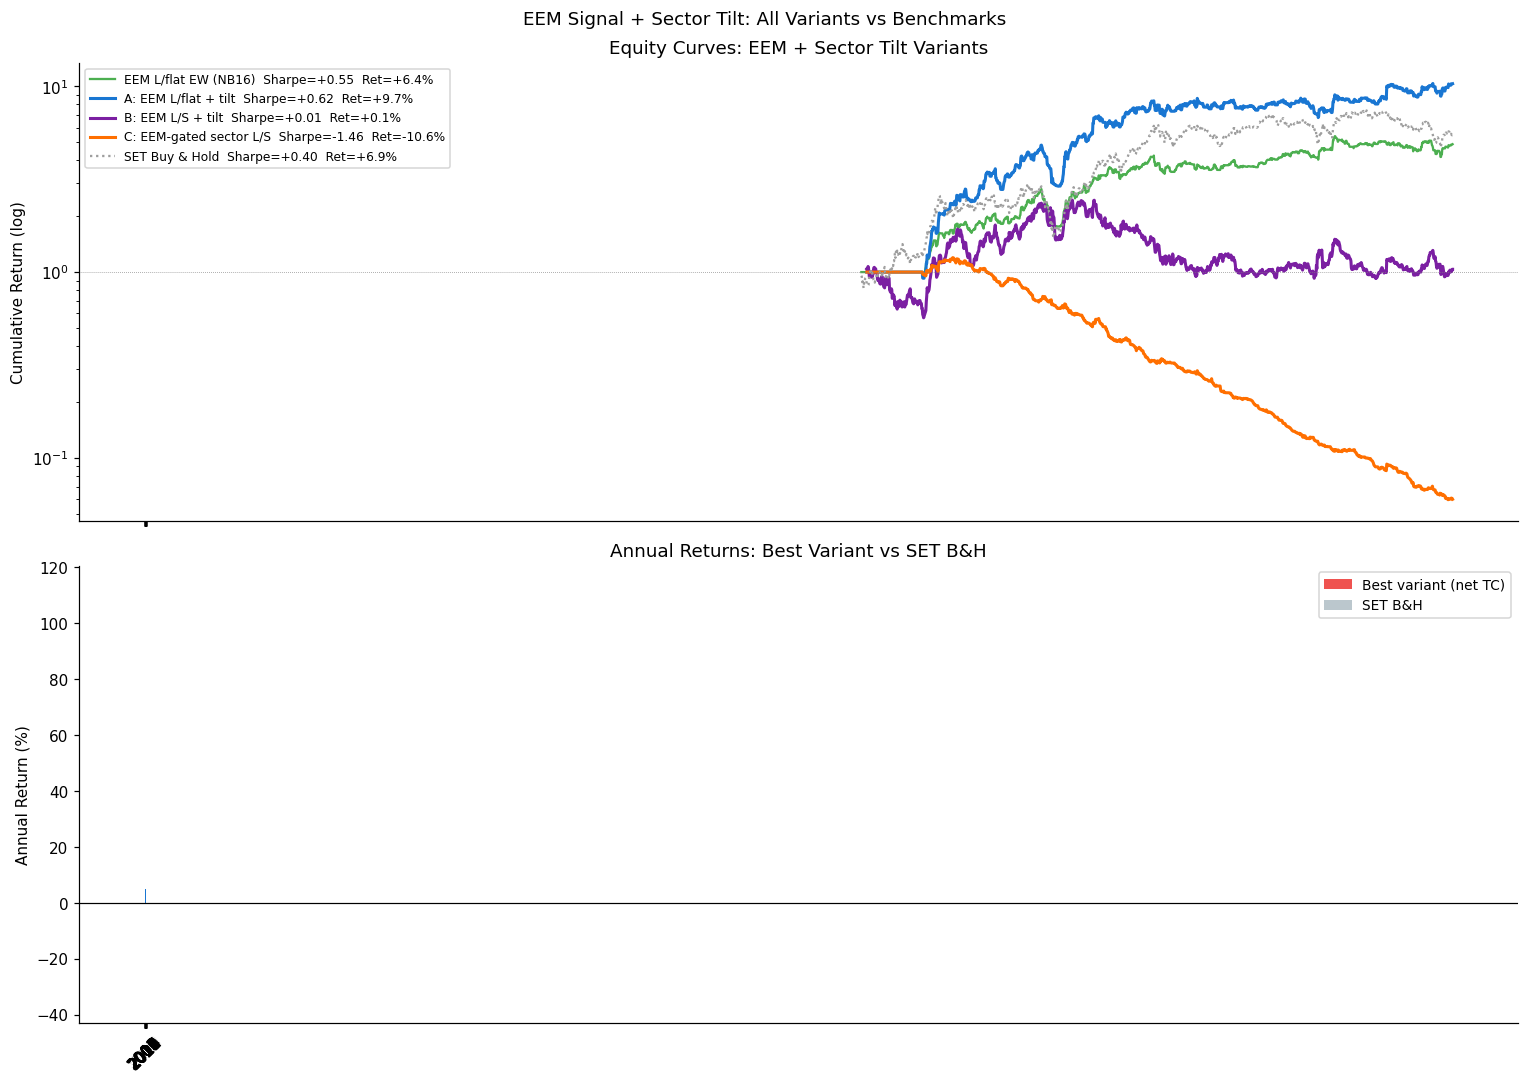

Saved: figs/eem_sector_equity.png


In [7]:
# ── Equity curves ──
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('EEM Signal + Sector Tilt: All Variants vs Benchmarks', fontsize=12)

plot_config = [
    (net_eem_lf,      'EEM L/flat EW (NB16)',     '#4CAF50', '-',  1.5),
    (res_A['net_ret'],'A: EEM L/flat + tilt',     '#1976D2', '-',  2.0),
    (res_B['net_ret'],'B: EEM L/S + tilt',        '#7B1FA2', '-',  2.0),
    (res_C['net_ret'],'C: EEM-gated sector L/S',  '#FF6F00', '-',  2.0),
    (bnh,             'SET Buy & Hold',            '#9E9E9E', ':',  1.5),
]

ax = axes[0]
for rets, lbl, col, ls, lw in plot_config:
    m   = risk_metrics(rets)
    cum = (1 + rets.dropna()).cumprod()
    ax.plot(cum, lw=lw, ls=ls, color=col,
            label=f'{lbl}  Sharpe={m["sharpe"]:+.2f}  Ret={m["ann_ret"]:+.1%}')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title('Equity Curves: EEM + Sector Tilt Variants')

# Annual returns for best variant
best_net = max(
    [res_A['net_ret'], res_B['net_ret'], res_C['net_ret'], net_eem_lf],
    key=lambda r: risk_metrics(r).get('sharpe', -999)
)
annual_best = best_net.groupby(best_net.index.year).apply(lambda r: (1+r).prod()-1)
annual_bnh  = bnh.groupby(bnh.index.year).apply(lambda r: (1+r).prod()-1)
ax2 = axes[1]
x = range(len(annual_best))
w = 0.35
ax2.bar([i-w/2 for i in x], annual_best*100, w,
        color=['#1976D2' if v>0 else '#EF5350' for v in annual_best],
        label='Best variant (net TC)')
ax2.bar([i+w/2 for i in x], annual_bnh*100, w,
        color='#78909C', alpha=0.5, label='SET B&H')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(annual_best.index, rotation=45)
ax2.set_ylabel('Annual Return (%)')
ax2.set_title('Annual Returns: Best Variant vs SET B&H')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'eem_sector_equity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/eem_sector_equity.png')

---
## Section 7 — Verdict: Does the Combination Add Value?

In [8]:
from scipy.stats import ttest_1samp

def score_strat(net_ret, gross_ret, label):
    m  = risk_metrics(net_ret)
    mg = risk_metrics(gross_ret)
    if not m: return 0
    annual = net_ret.groupby(net_ret.index.year).apply(lambda r: (1+r).prod()-1)
    _, p_ret = ttest_1samp(net_ret.dropna(), 0)
    ev = [
        ('Gross Sharpe > 0.5',          mg['sharpe'],             mg['sharpe'] > 0.5),
        ('Net Sharpe > 0.5',            m['sharpe'],              m['sharpe'] > 0.5),
        ('Net Sharpe > EEM L/flat(0.58)',m['sharpe'],              m['sharpe'] > 0.58),
        ('Annual return > 7%',          m['ann_ret'],             m['ann_ret'] > 0.07),
        ('Max DD > -40%',               m['max_dd'],              m['max_dd'] > -0.40),
        ('Positive years > 60%',        (annual>0).mean(),        (annual>0).mean() > 0.60),
        ('Win rate > 52%',              m['win_rate'],            m['win_rate'] > 0.52),
        ('Return t-test p < 0.05',      p_ret,                    p_ret < 0.05),
    ]
    score = sum(1 for *_, p in ev if p)
    print(f'\n{label}  (Score {score}/{len(ev)})')
    print('-' * 56)
    for desc, val, passed in ev:
        mark = '[+]' if passed else '[-]'
        if abs(val) < 2:
            print(f'  {mark} {desc:<38} {val:>+.3f}')
        else:
            print(f'  {mark} {desc:<38} {val:>+.1%}')
    return score

print('='*60)
print('EEM + SECTOR TILT VERDICT')
print('='*60)

scores = {}
scores['EEM L/flat EW (benchmark)'] = score_strat(net_eem_lf,      gross_eem_lf,      'EEM L/flat EW (NB16 benchmark)')
scores['Variant A']                 = score_strat(res_A['net_ret'], res_A['gross_ret'], 'A: EEM L/flat + sector tilt')
scores['Variant B']                 = score_strat(res_B['net_ret'], res_B['gross_ret'], 'B: EEM L/S + sector tilt')
scores['Variant C']                 = score_strat(res_C['net_ret'], res_C['gross_ret'], 'C: EEM-gated sector L/S')

best = max(scores, key=lambda k: scores[k])
print(f'\n{"="*60}')
print('SUMMARY')
print(f'{"="*60}')
for name, s in scores.items():
    improvement = s - scores['EEM L/flat EW (benchmark)']
    marker = ' ← BEST' if name == best else ''
    imp_str = f'(+{improvement} vs benchmark)' if improvement > 0 else f'({improvement} vs benchmark)'
    print(f'  {name:<32} Score={s}/8  {imp_str}{marker}')

bench_sharpe = risk_metrics(net_eem_lf)['sharpe']
best_sharpe  = max(risk_metrics(r)['sharpe'] for r in
                   [res_A['net_ret'], res_B['net_ret'], res_C['net_ret']])
if best_sharpe > bench_sharpe + 0.05:
    print(f'\n=> COMBINATION ADDS VALUE: best variant Sharpe {best_sharpe:+.2f} vs benchmark {bench_sharpe:+.2f}')
else:
    print(f'\n=> COMBINATION MARGINAL: best variant Sharpe {best_sharpe:+.2f} vs benchmark {bench_sharpe:+.2f}')
    print('   EEM signal alone captures most of the alpha.')

EEM + SECTOR TILT VERDICT

EEM L/flat EW (NB16 benchmark)  (Score 5/8)
--------------------------------------------------------
  [+] Gross Sharpe > 0.5                     +0.761
  [+] Net Sharpe > 0.5                       +0.551
  [-] Net Sharpe > EEM L/flat(0.58)          +0.551
  [-] Annual return > 7%                     +0.064
  [+] Max DD > -40%                          -0.384
  [+] Positive years > 60%                   +0.615
  [-] Win rate > 52%                         +0.272
  [+] Return t-test p < 0.05                 +0.003

A: EEM L/flat + sector tilt  (Score 7/8)
--------------------------------------------------------
  [+] Gross Sharpe > 0.5                     +1.130
  [+] Net Sharpe > 0.5                       +0.624
  [+] Net Sharpe > EEM L/flat(0.58)          +0.624
  [+] Annual return > 7%                     +0.097
  [+] Max DD > -40%                          -0.399
  [+] Positive years > 60%                   +0.615
  [-] Win rate > 52%                         